# Step 3: Compute a force directed layout

- implement a force directed layout;
- explain your choice of forces/parameters
- draw the result (Les Misérables network and Jazz network)
- comment on the quality of the resulting drawing; which (other) quality metrics could be optimized to improve your results?


- make it scalable for hyper parameter tuning for every graph; <- with grid search

## setup

libraries:

In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path

graphs' datasets:

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/Step1/JazzNetwork.dot" #tree
data_name_2 = "../Dataset/Step1/LesMiserables.dot" #tree
data_name_3 = "../Dataset/OTHERS/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/OTHERS/g.20.27.dot"
data_name_5 = "../Dataset/OTHERS/g.42.88.dot"
data_name_6 = "../Dataset/OTHERS/GD97.dot"
data_name_7 = "../Dataset/OTHERS/LeagueNetwork.dot" #tree
data_name_8 = "../Dataset/OTHERS/mesh graph.dot"
data_name_9 = "../Dataset/OTHERS/noname.dot"
data_name_10 = "../Dataset/OTHERS/polblogs.dot"
data_name_11 = "../Dataset/OTHERS/robot graph.dot"
data_name_12 = "../Dataset/OTHERS/rome.dot" #tree
data_name_13 = "../Dataset/OTHERS/snail graph.dot"

functions:

In [3]:
def draw_force_directed_graph_fruchterman_reingold(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001):
    # Create output directory if it doesn't exist
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    
    # Clean graph name for use as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    
    # Number of nodes
    n = len(nodes)
    print(f"Number of nodes: {n}")
    
    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    print(f"Canvas dimensions: {width} x {height}, area: {area}")
    
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size inversely proportional to sqrt(n)
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    print(f"Node size: {node_size}, Font size: {font_size}")
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    print(f"Calculated l value: {l}")
    
    # SCALING: Initial temperature scales with canvas size
    t = width / 10
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    # SCALING: Adjust convergence threshold based on canvas size
    scaled_convergence = convergence_threshold * scale_factor
    
    # For each iteration
    i = 0
    while i < iterations and max_movement > scaled_convergence:
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both endpoints of the edge
            f_attr[u] += direction * attractive_magnitude
            f_attr[v] -= direction * attractive_magnitude
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        # Proportional cooling
        t = t * 0.95
        
        # Draw the graph every 10 iterations or at the last iteration or if converges
        if i % 10 == 0 or i == iterations - 1 or max_movement <= scaled_convergence:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', 
                         fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.1 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
    
    # Show convergence message
    if max_movement <= scaled_convergence:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    return pos  # Return final node positions

## usage:

Number of nodes: 77
Canvas dimensions: 2.1937410968480306 x 2.1937410968480306, area: 4.812500000000001
Node size: 91.16846116771035, Font size: 4
Calculated l value: 0.25
Saved frame 1 to ../Outputs_force/LesMiserables_FR_C1_iter_0001.png


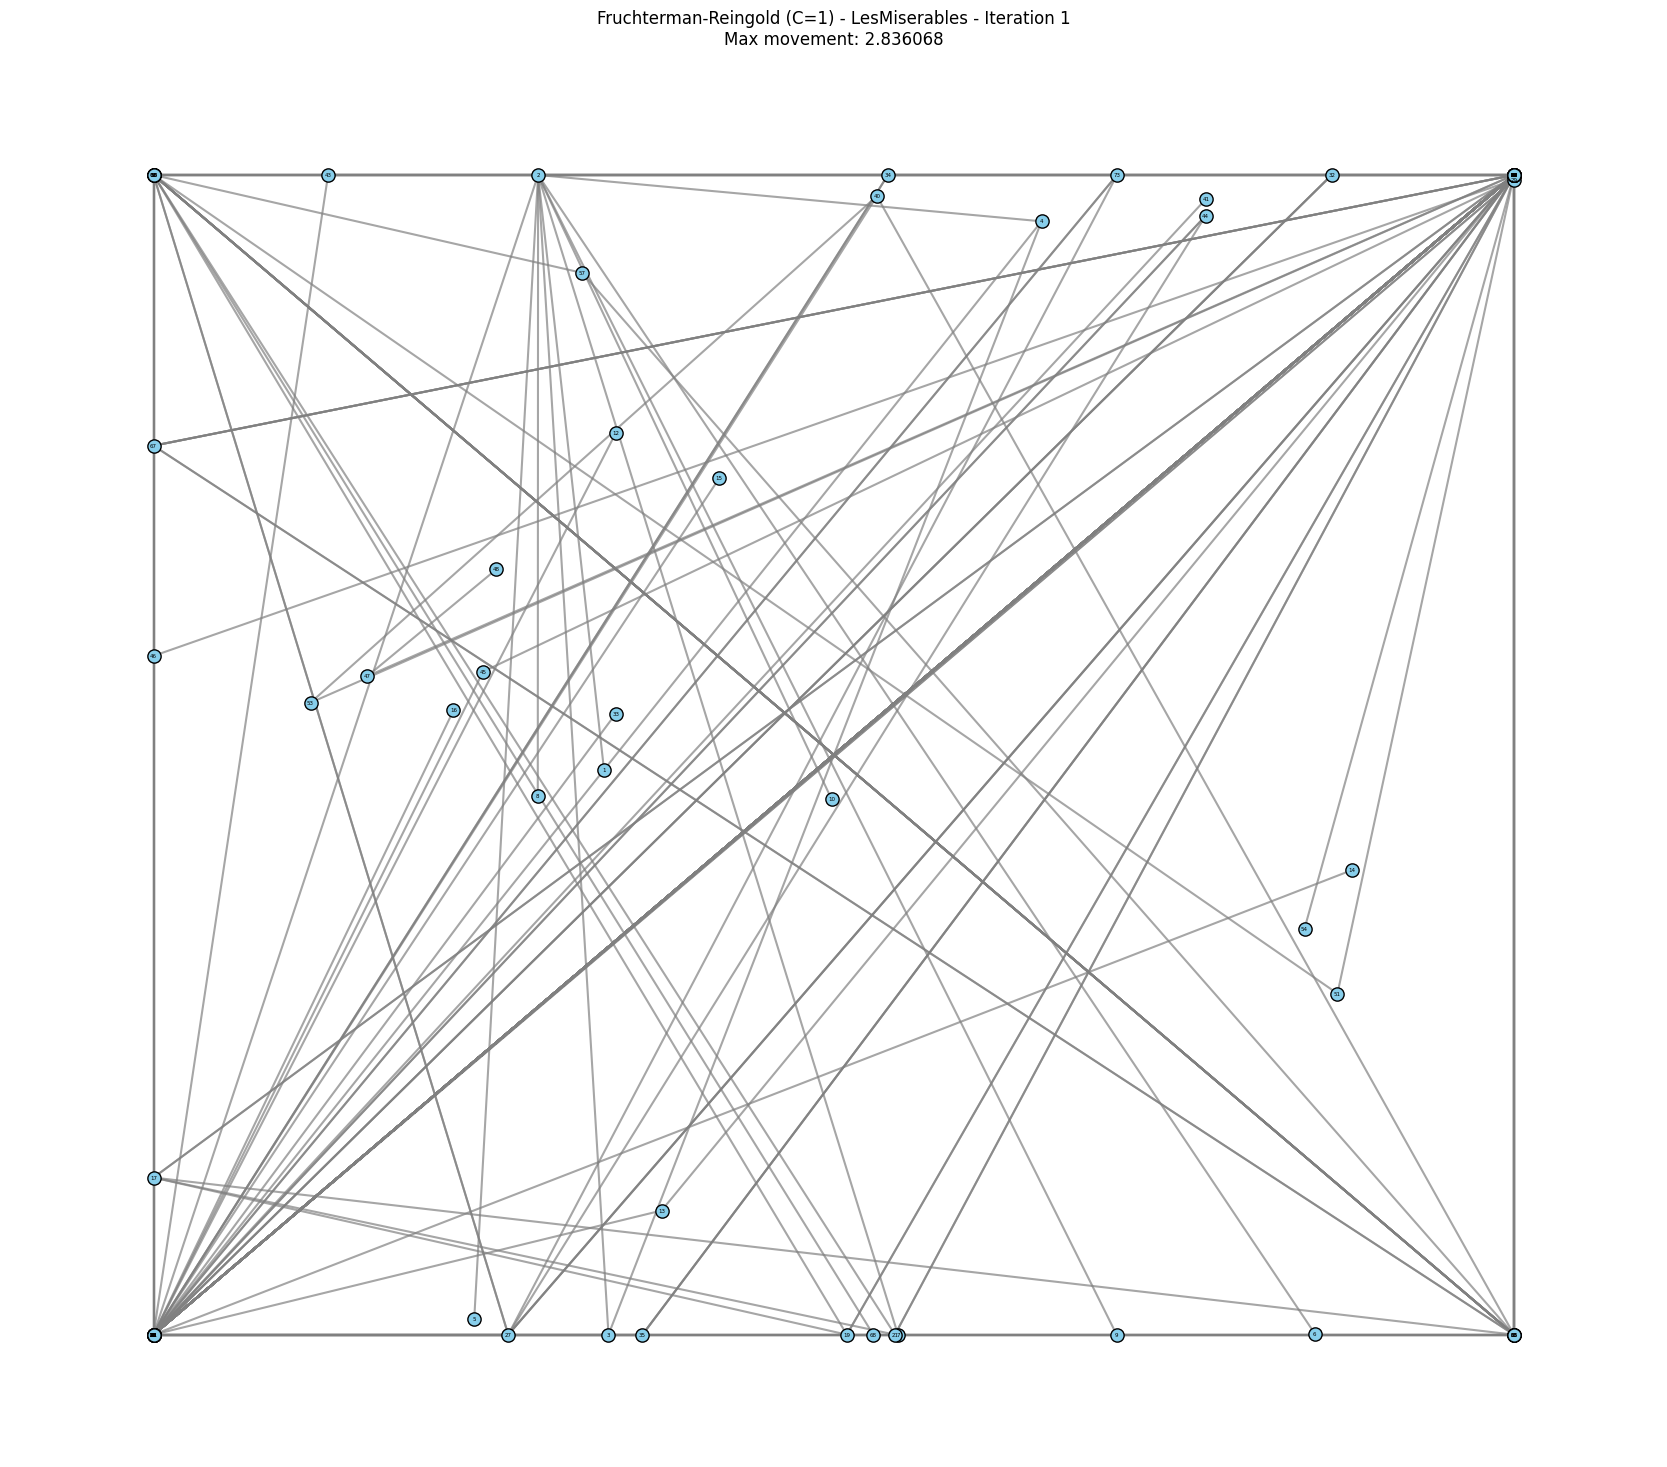

Saved frame 11 to ../Outputs_force/LesMiserables_FR_C1_iter_0011.png


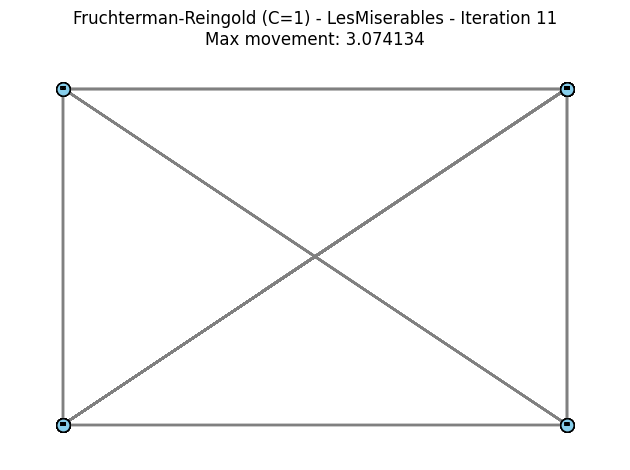

Saved frame 21 to ../Outputs_force/LesMiserables_FR_C1_iter_0021.png


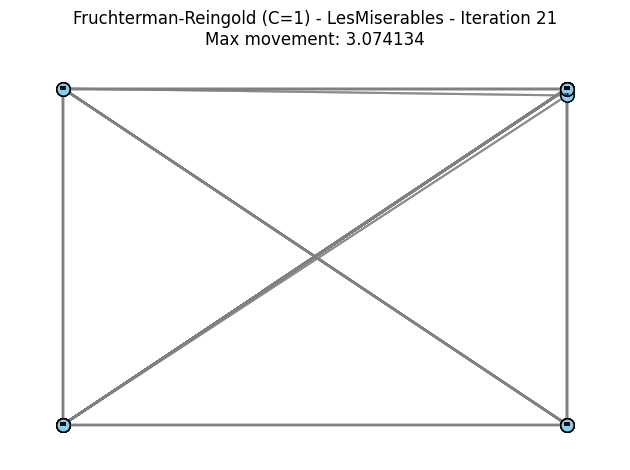

Saved frame 31 to ../Outputs_force/LesMiserables_FR_C1_iter_0031.png


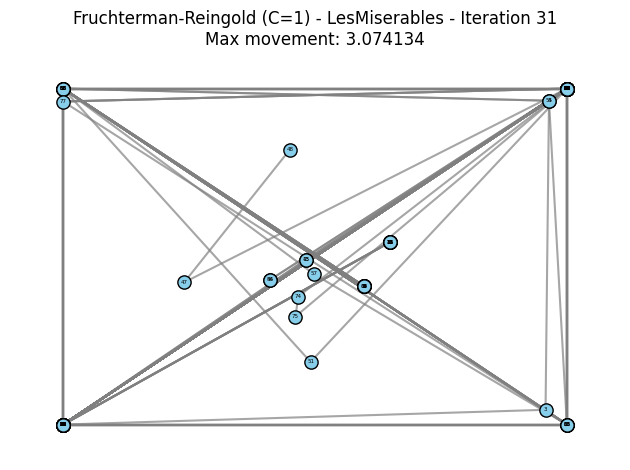

Saved frame 41 to ../Outputs_force/LesMiserables_FR_C1_iter_0041.png


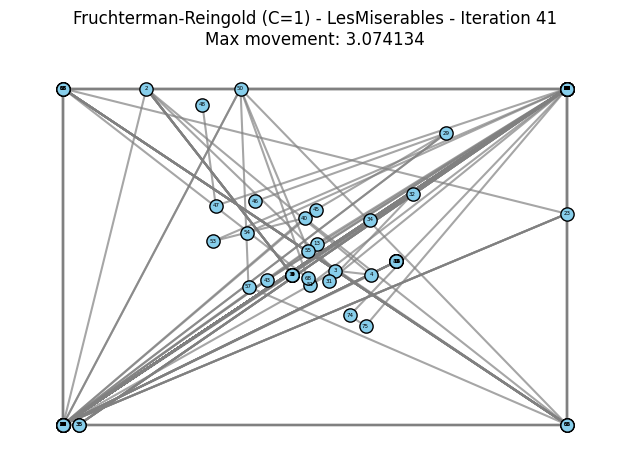

Saved frame 51 to ../Outputs_force/LesMiserables_FR_C1_iter_0051.png


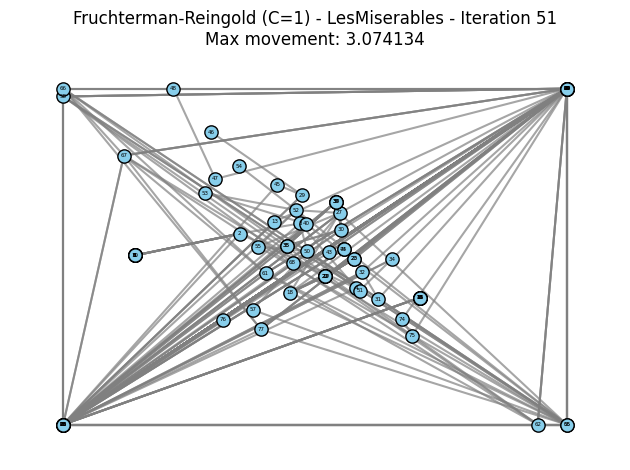

Saved frame 61 to ../Outputs_force/LesMiserables_FR_C1_iter_0061.png


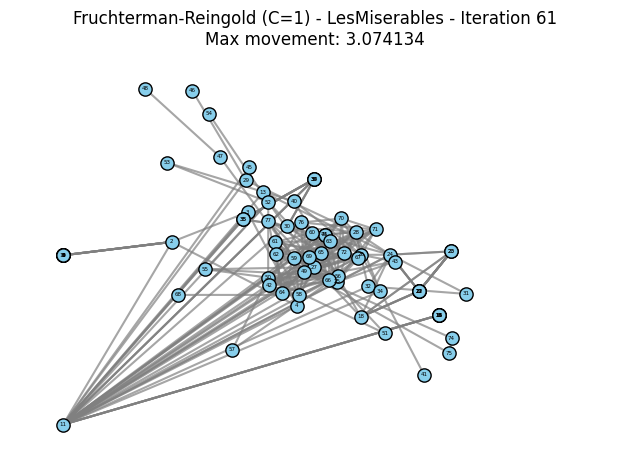

Saved frame 71 to ../Outputs_force/LesMiserables_FR_C1_iter_0071.png


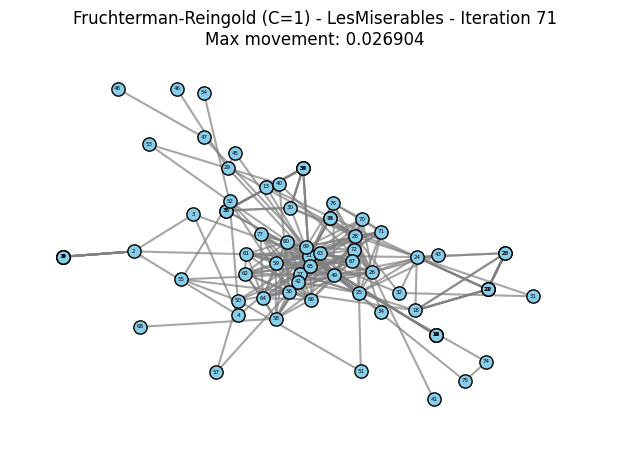

Saved frame 81 to ../Outputs_force/LesMiserables_FR_C1_iter_0081.png


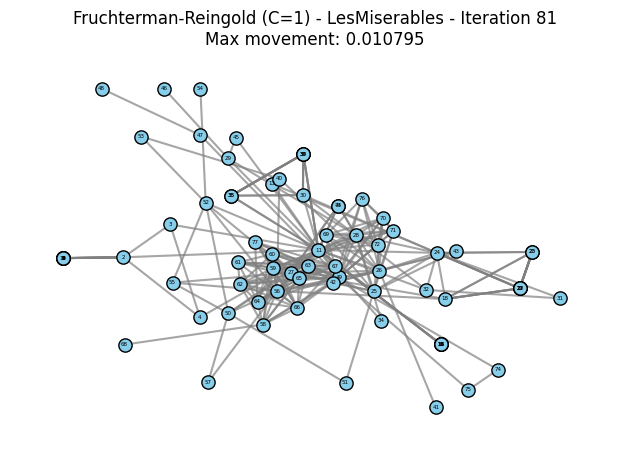

Saved frame 91 to ../Outputs_force/LesMiserables_FR_C1_iter_0091.png


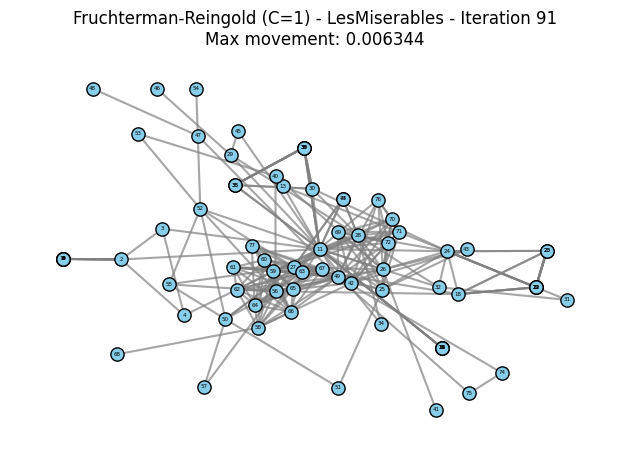

Saved frame 101 to ../Outputs_force/LesMiserables_FR_C1_iter_0101.png


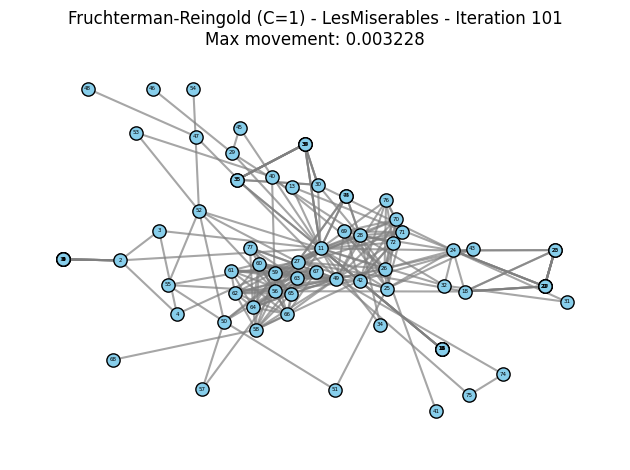

Saved frame 107 to ../Outputs_force/LesMiserables_FR_C1_iter_0107.png


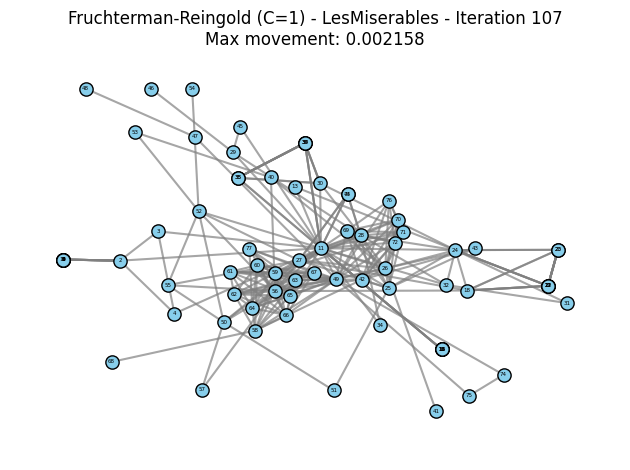

Algorithm converged at iteration 107 with maximum movement 0.002158


{'1': array([0.01      , 1.07783507]),
 '2': array([0.25530214, 1.07017559]),
 '3': array([0.41888129, 1.26008114]),
 '4': array([0.49030286, 0.72795809]),
 '5': array([0.01      , 1.07783507]),
 '6': array([0.01      , 1.07783507]),
 '7': array([0.01      , 1.07783507]),
 '8': array([0.01      , 1.07783507]),
 '9': array([0.01      , 1.07783507]),
 '10': array([0.01      , 1.07783507]),
 '11': array([1.12255638, 1.15093238]),
 '12': array([1.64377406, 0.49600326]),
 '13': array([1.01018368, 1.54804772]),
 '14': array([1.64377406, 0.49600326]),
 '15': array([1.64377406, 0.49600326]),
 '16': array([1.64377406, 0.49600326]),
 '24': array([1.70265325, 1.13875683]),
 '25': array([1.41453571, 0.89170563]),
 '26': array([1.39994309, 1.02008785]),
 '27': array([1.02830941, 1.072028  ]),
 '28': array([1.29429111, 1.2331889 ]),
 '29': array([0.74247523, 1.7720201 ]),
 '30': array([1.11899005, 1.57120258]),
 '32': array([1.663658  , 0.91270028]),
 '33': array([1.64377406, 0.49600326]),
 '34': ar

In [5]:
# Path to your .dot file
dot_file_path = data_name_2

# Draw the graph with the Fruchterman-Reingold algorithm
draw_force_directed_graph_fruchterman_reingold(
    dot_file_path, 
    iterations=200,
    C=1,
    convergence_threshold=0.001
)